# Task 3

### Build a decision tree classifier to predict whether a customer will purchase a product or service based on their demographic and behavioural data. use a dataset such as the bank marketing dataset from the UCI machine learning repository.

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Load Database

In [3]:
df = pd.read_csv("bank.csv", delimiter=';')

## Rename Column "y" to "Deposit"

In [4]:
df.rename(columns={'y':'deposit'}, inplace=True)

## View first five records

In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Plot Graph

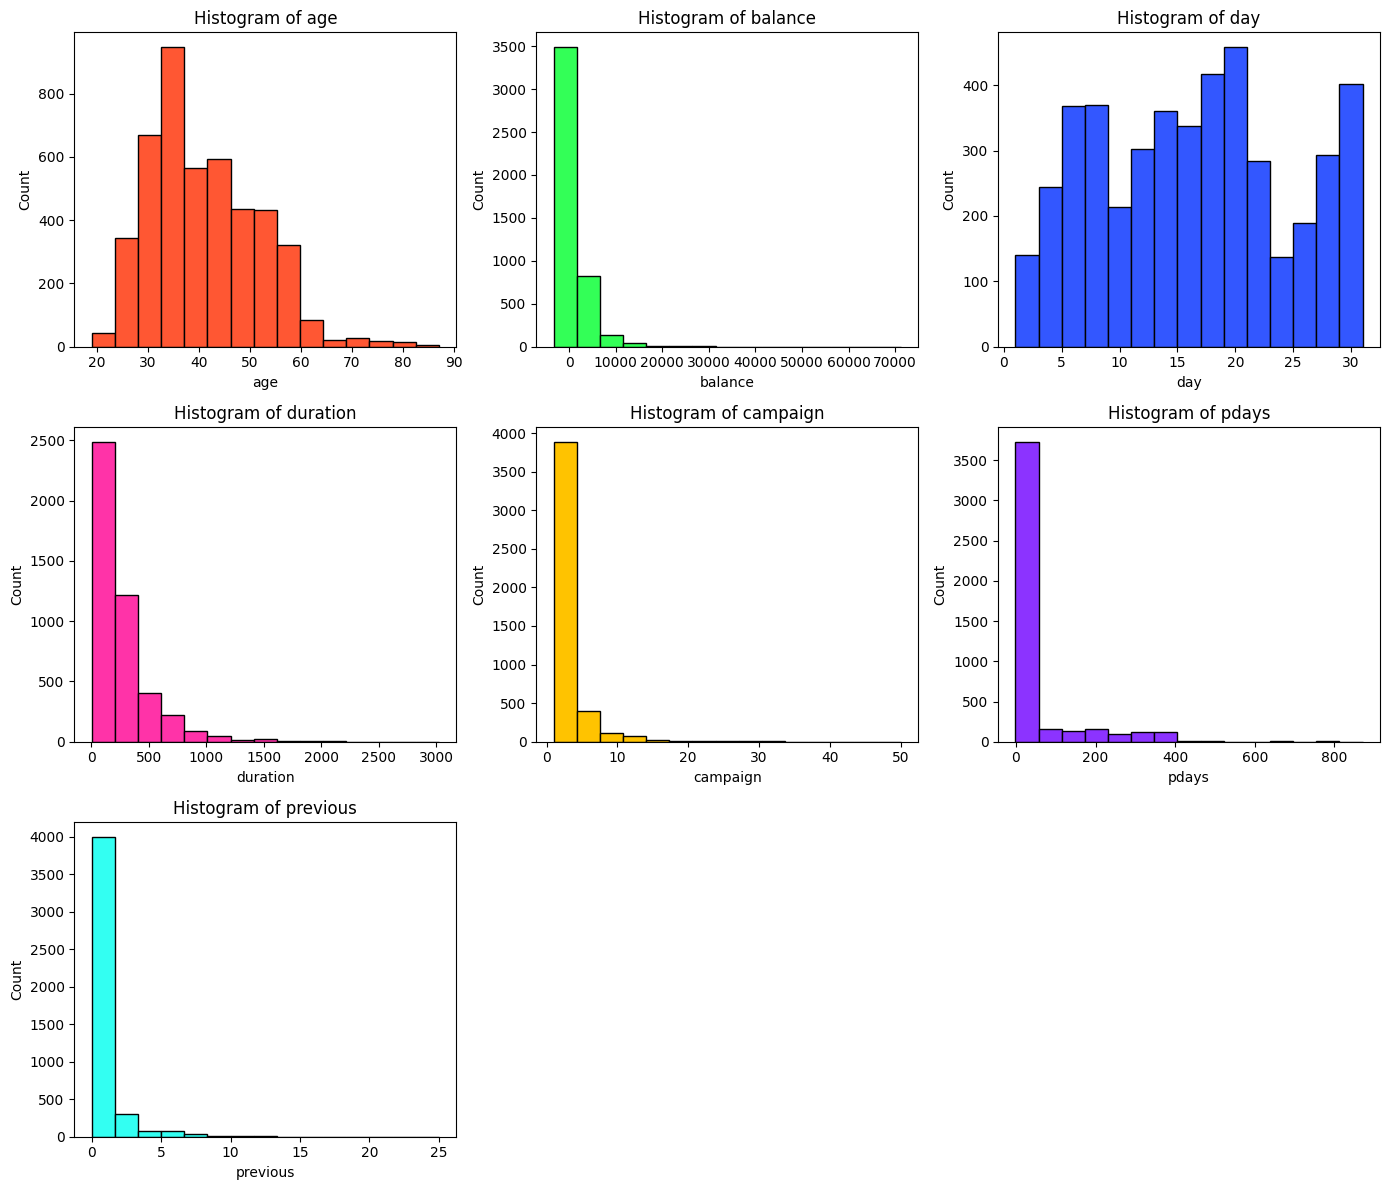

In [6]:
# Numeric columns
num_cols = ['age','balance','day','duration','campaign','pdays','previous']

# Colors for each column
colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A8', '#FFC300', '#8C33FF', '#33FFF2']

plt.figure(figsize=(14,12))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)  # 3 rows, 3 columns
    plt.hist(df[col], bins=15, color=colors[i], edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

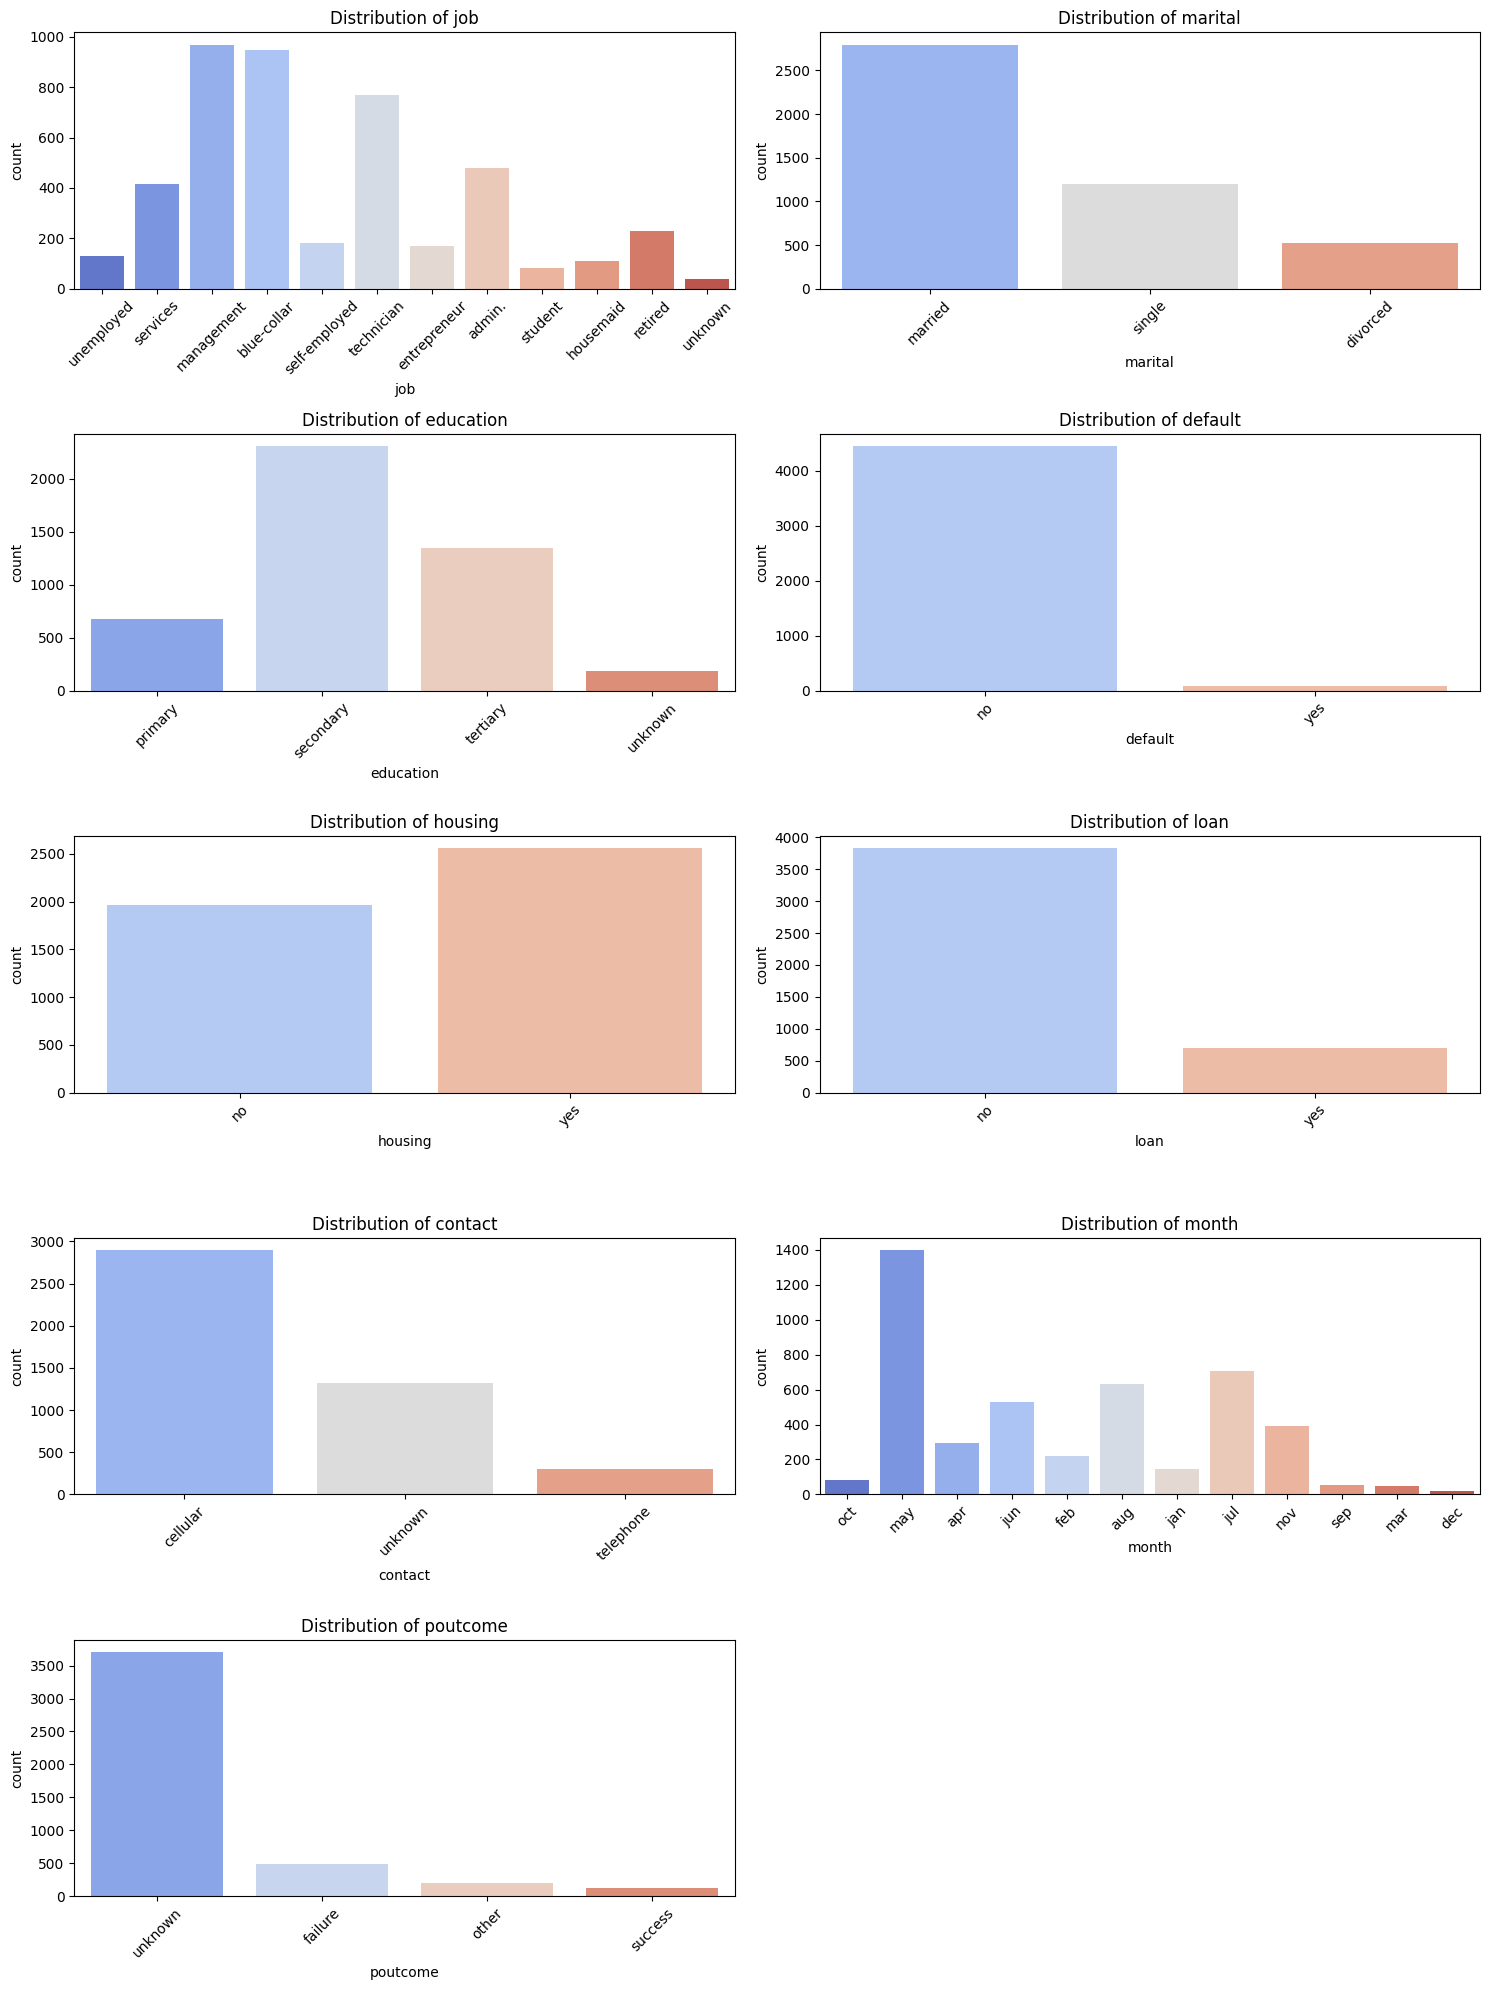

In [7]:
cat_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome']
plt.figure(figsize=(15,20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot((len(cat_cols)+1)//2, 2, i)
    sns.countplot(x=col, data=df, palette='coolwarm')
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Preprocess Data

In [8]:
le = LabelEncoder()
for col in cat_cols + ['deposit']:
    df[col] = le.fit_transform(df[col])

## Split Features and Target

In [9]:
X = df.drop('deposit', axis=1)  # independent variables
y = df['deposit']                # target

## Split into Train and Test

In [10]:

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train Decision Tree

In [11]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10, random_state=42)
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

### In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
### On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.
## Vertical Bar Plot for Feature Importance

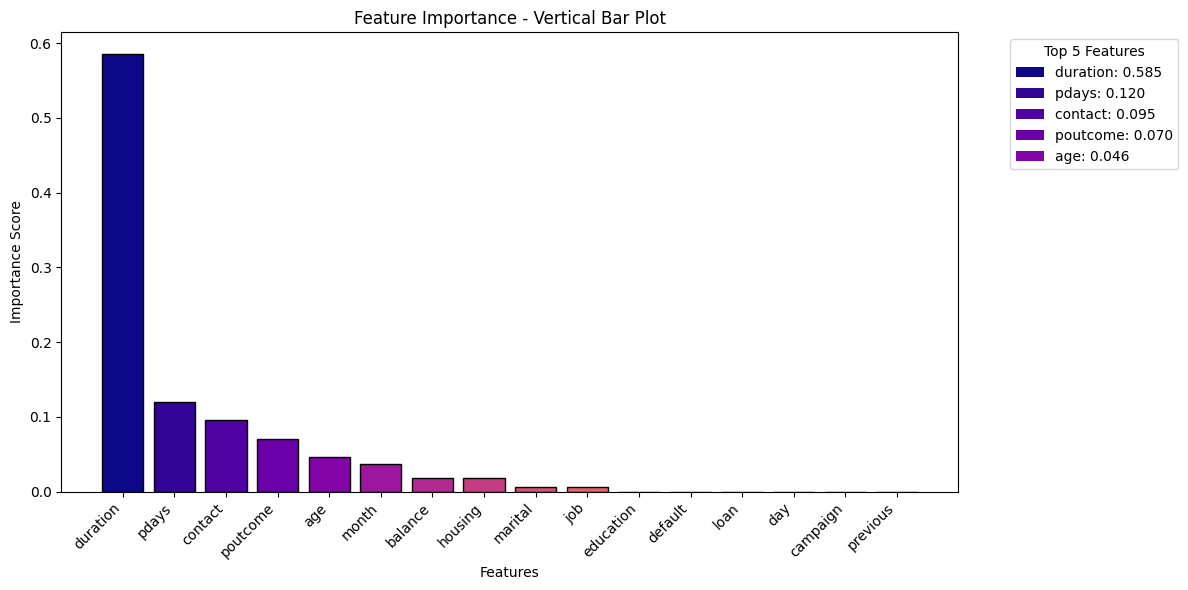

In [12]:
import matplotlib.cm as cm

# Feature importance
feat_importance = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

# Colors: use a colormap
colors = cm.plasma(np.linspace(0,1,len(feat_importance)))

plt.figure(figsize=(12,6))
bars = plt.bar(feat_importance.index, feat_importance.values, color=colors, edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.title("Feature Importance - Vertical Bar Plot")

# Add legend for top 5 features
top5 = feat_importance[:5]
for i, value in enumerate(top5):
    plt.bar(0,0, color=colors[i], label=f"{top5.index[i]}: {top5.values[i]:.3f}")
plt.legend(title="Top 5 Features", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## Visualize Decision Tree

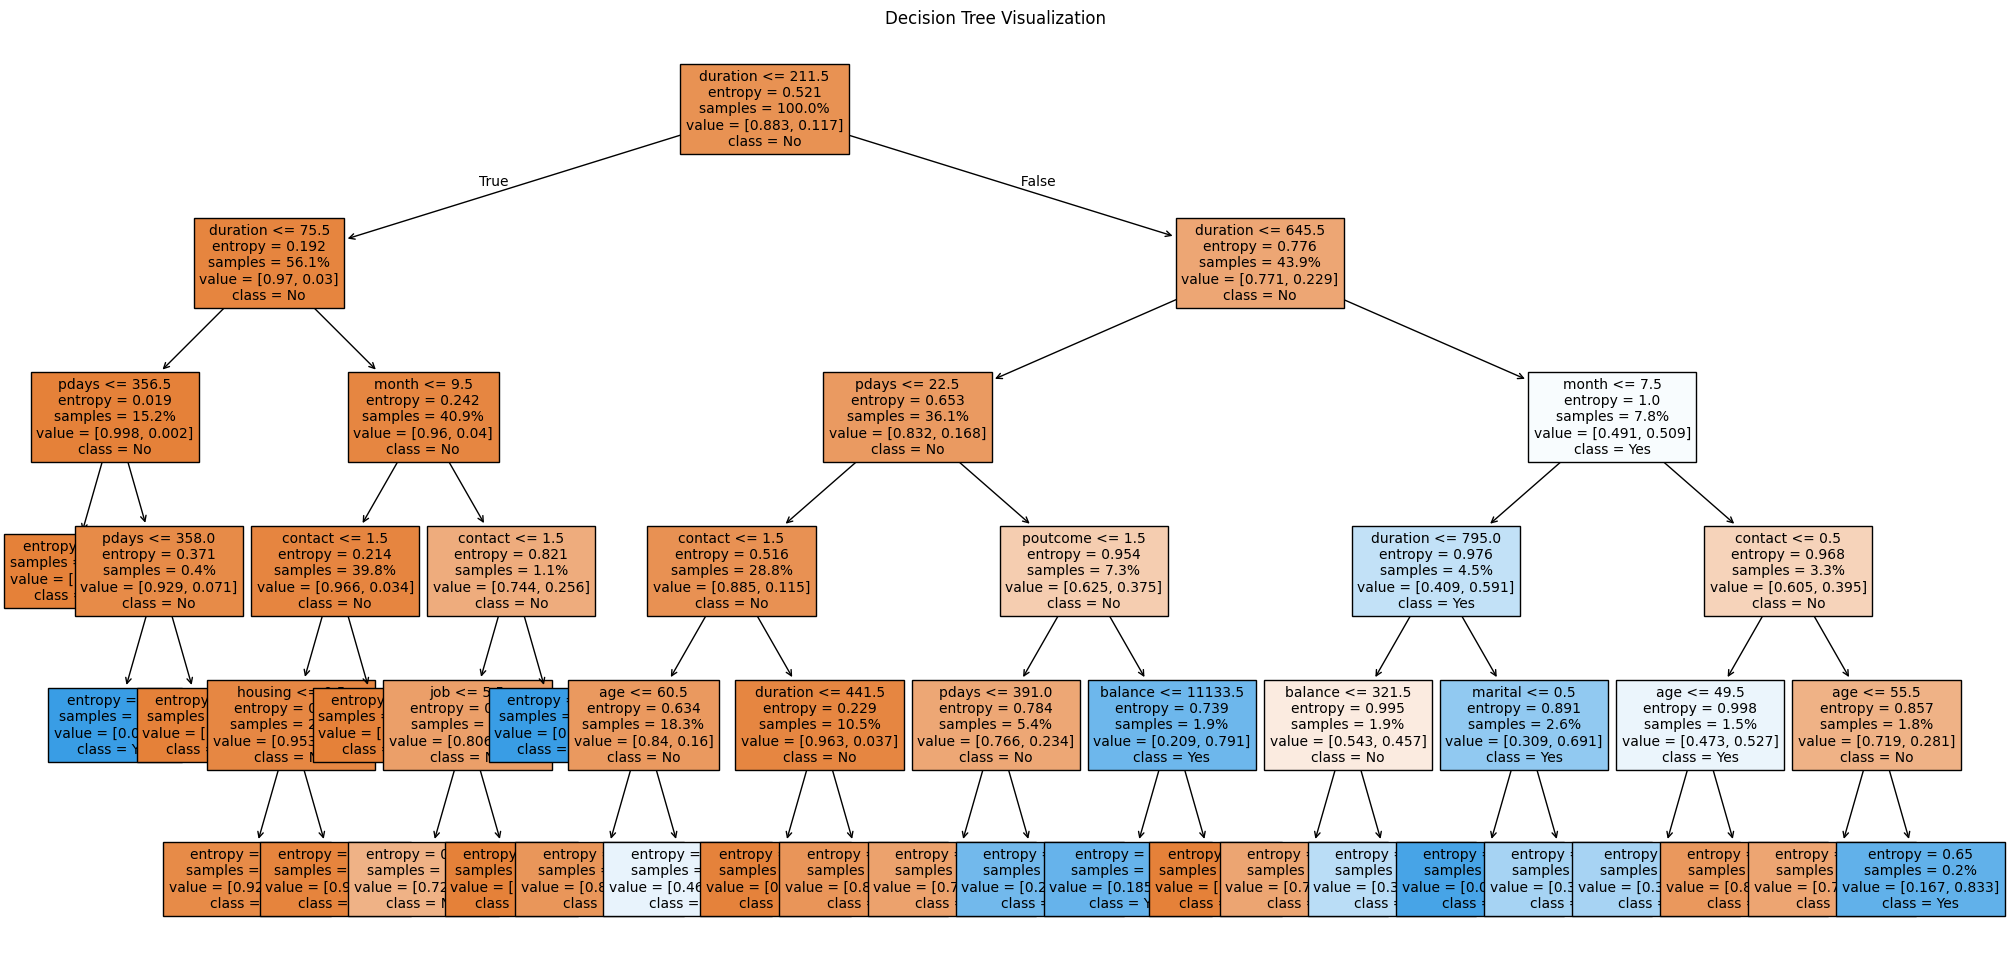

In [13]:
plt.figure(figsize=(25,12))
plot_tree(dt, feature_names=X.columns, class_names=['No','Yes'], filled=True, fontsize=10, proportion=True)
plt.title("Decision Tree Visualization")
plt.show()